In [ ]:
# Cell 1 — Imports:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# Cell 2 — Load the data:

import os

# Set working directory to project root
os.chdir('/Users/niravparmar/retail-fraud-detection')

# Verify we're in the right place
print("Working directory:", os.getcwd())
print("Files in data/raw:", os.listdir('data/raw'))

# Load transaction data
print("\nLoading transaction data...")
train_tx = pd.read_csv('data/raw/train_transaction.csv')
train_id = pd.read_csv('data/raw/train_identity.csv')

print(f"Transaction data shape: {train_tx.shape}")
print(f"Identity data shape:    {train_id.shape}")

Working directory: /Users/niravparmar/retail-fraud-detection
Files in data/raw: ['test_transaction.csv', 'train_identity.csv', 'ieee-fraud-detection.zip', 'test_identity.csv', 'sample_submission.csv', 'train_transaction.csv']

Loading transaction data...
Transaction data shape: (590540, 394)
Identity data shape:    (144233, 41)


In [ ]:
# Cell 3 — First look at the data:

# First 5 rows
print("=== TRANSACTION DATA — FIRST LOOK ===")
train_tx[['TransactionID','isFraud','TransactionAmt',
          'ProductCD','card4','card6','P_emaildomain']].head()

=== TRANSACTION DATA — FIRST LOOK ===


,TransactionID,isFraud,TransactionAmt,ProductCD,card4,card6,P_emaildomain
0,2987000,0,68.500,W,discover,credit,NaN
1,2987001,0,29.000,W,mastercard,credit,gmail.com
2,2987002,0,59.000,W,visa,debit,outlook.com
3,2987003,0,50.000,W,mastercard,debit,yahoo.com
4,2987004,0,50.000,H,mastercard,credit,gmail.com


Total transactions:  590,540
Fraudulent:          20,663
Legitimate:          569,877
Fraud rate:          3.50%


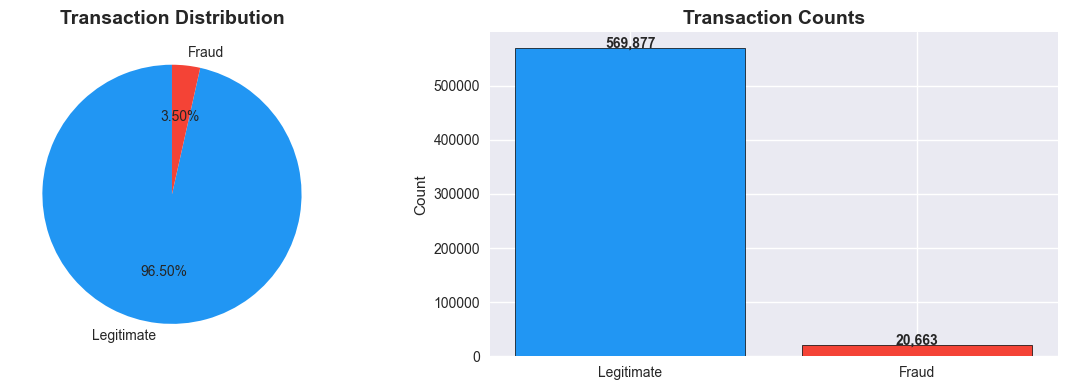

Chart saved to reports/figures/


In [ ]:
# Cell 4 — Fraud rate overview:

# How much fraud is in the dataset?
fraud_count = train_tx['isFraud'].value_counts()
fraud_rate  = train_tx['isFraud'].mean() * 100

print("=" * 40)
print(f"Total transactions:  {len(train_tx):,}")
print(f"Fraudulent:          {fraud_count[1]:,}")
print(f"Legitimate:          {fraud_count[0]:,}")
print(f"Fraud rate:          {fraud_rate:.2f}%")
print("=" * 40)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(fraud_count, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'],
            startangle=90)
axes[0].set_title('Transaction Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(['Legitimate', 'Fraud'], fraud_count.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Transaction Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/01_fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/figures/")

=== TRANSACTION AMOUNT ANALYSIS ===

Legitimate transactions:
  Mean:   $134.51
  Median: $68.50
  Max:    $31937.39

Fraudulent transactions:
  Mean:   $149.24
  Median: $75.00
  Max:    $5191.00


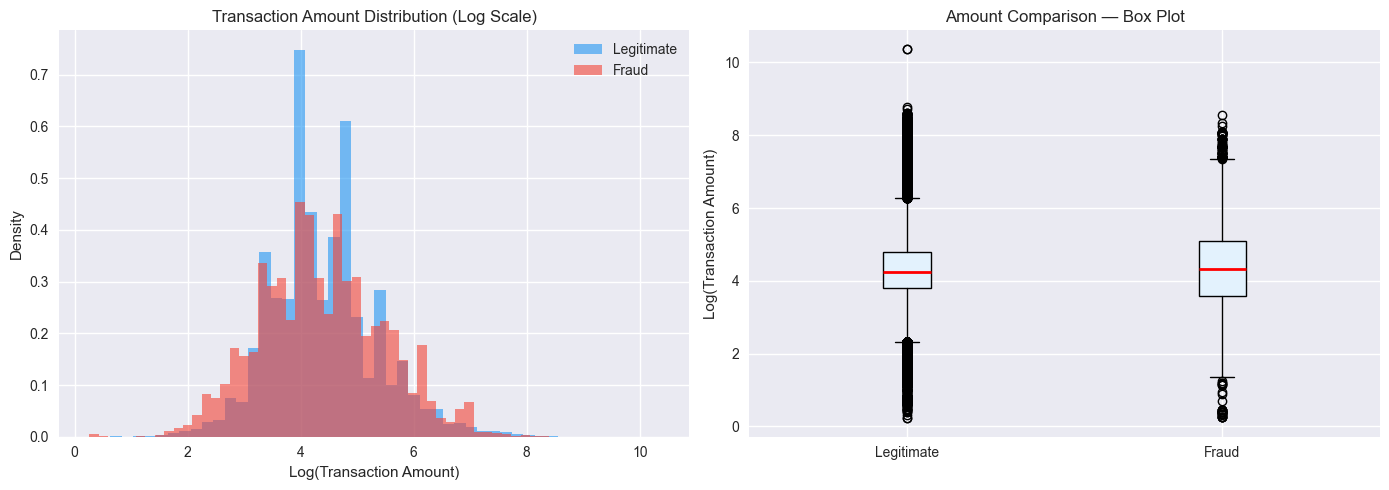

In [ ]:
# Cell 5 — Transaction amount analysis:

# How do fraud amounts compare to legitimate amounts?
fraud     = train_tx[train_tx['isFraud'] == 1]['TransactionAmt']
legit     = train_tx[train_tx['isFraud'] == 0]['TransactionAmt']

print("=== TRANSACTION AMOUNT ANALYSIS ===")
print(f"\nLegitimate transactions:")
print(f"  Mean:   ${legit.mean():.2f}")
print(f"  Median: ${legit.median():.2f}")
print(f"  Max:    ${legit.max():.2f}")
print(f"\nFraudulent transactions:")
print(f"  Mean:   ${fraud.mean():.2f}")
print(f"  Median: ${fraud.median():.2f}")
print(f"  Max:    ${fraud.max():.2f}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale distribution
axes[0].hist(np.log1p(legit), bins=50, alpha=0.6,
             color='#2196F3', label='Legitimate', density=True)
axes[0].hist(np.log1p(fraud), bins=50, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[0].set_xlabel('Log(Transaction Amount)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0].legend()

# Box plot
axes[1].boxplot([np.log1p(legit), np.log1p(fraud)],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Log(Transaction Amount)')
axes[1].set_title('Amount Comparison — Box Plot')

plt.tight_layout()
plt.savefig('reports/figures/02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

=== FRAUD BY PRODUCT CATEGORY ===
           Fraud Rate %  Fraud Count   Total
ProductCD                                   
C                11.687         8008   68519
S                 5.900          686   11628
H                 4.766         1574   33024
R                 3.783         1426   37699
W                 2.040         8969  439670


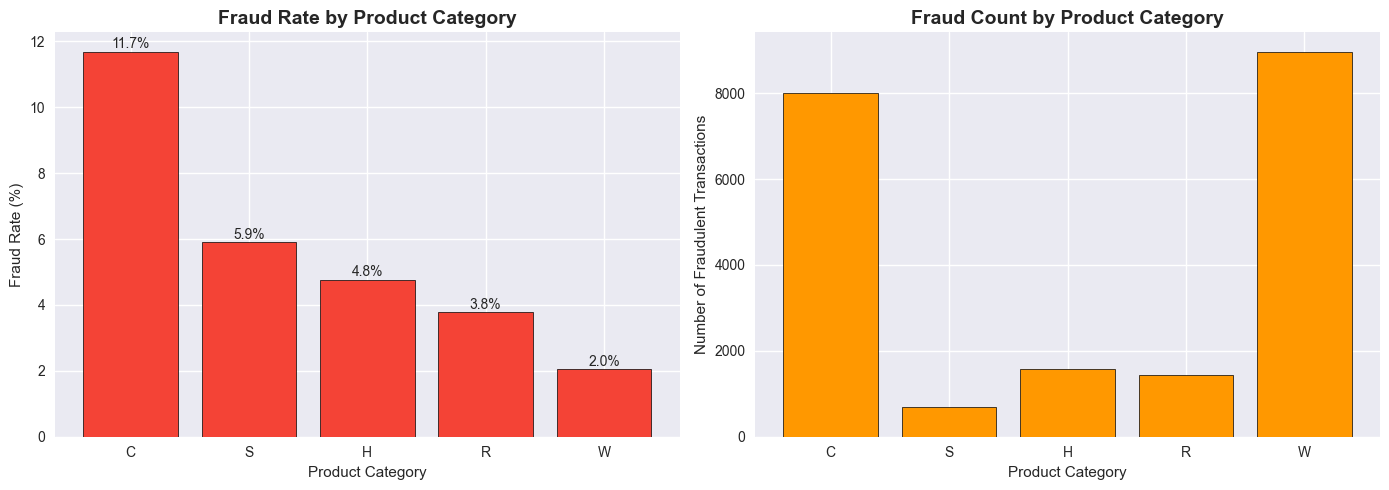

In [ ]:
# Cell 6 — Fraud by product category:

# Which product types have highest fraud rates?
product_fraud = train_tx.groupby('ProductCD')['isFraud'].agg(['mean','sum','count'])
product_fraud.columns = ['Fraud Rate', 'Fraud Count', 'Total']
product_fraud['Fraud Rate %'] = product_fraud['Fraud Rate'] * 100
product_fraud = product_fraud.sort_values('Fraud Rate %', ascending=False)

print("=== FRAUD BY PRODUCT CATEGORY ===")
print(product_fraud[['Fraud Rate %', 'Fraud Count', 'Total']].to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(product_fraud.index, product_fraud['Fraud Rate %'],
            color='#F44336', edgecolor='black', linewidth=0.5)
axes[0].set_title('Fraud Rate by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Fraud Rate (%)')
for i, (idx, row) in enumerate(product_fraud.iterrows()):
    axes[0].text(i, row['Fraud Rate %'] + 0.1,
                 f"{row['Fraud Rate %']:.1f}%", ha='center', fontsize=10)

axes[1].bar(product_fraud.index, product_fraud['Fraud Count'],
            color='#FF9800', edgecolor='black', linewidth=0.5)
axes[1].set_title('Fraud Count by Product Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Number of Fraudulent Transactions')

plt.tight_layout()
plt.savefig('reports/figures/03_fraud_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

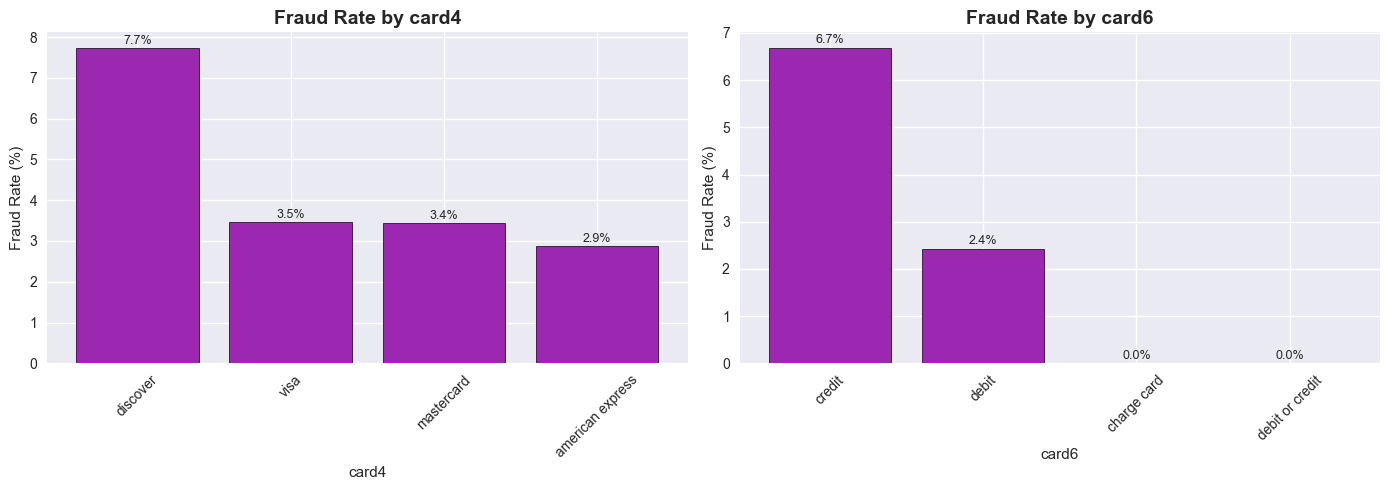

In [ ]:
# Cell 7 — Fraud by card type:

# Which card types are most targeted?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(['card4', 'card6']):
    card_fraud = train_tx.groupby(col)['isFraud'].mean() * 100
    card_fraud = card_fraud.sort_values(ascending=False).dropna()

    axes[idx].bar(card_fraud.index, card_fraud.values,
                  color='#9C27B0', edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'Fraud Rate by {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Fraud Rate (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    for i, (idx2, val) in enumerate(card_fraud.items()):
        axes[idx].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/figures/04_fraud_by_card.png', dpi=150, bbox_inches='tight')
plt.show()

Columns with missing values: 374 out of 394

Top 20 columns with most missing data:
dist2   93.628
D7      93.410
D13     89.509
D14     89.469
D12     89.041
D6      87.607
D9      87.312
D8      87.312
V153    86.124
V139    86.124
V162    86.124
V161    86.124
V154    86.124
V138    86.124
V158    86.124
V157    86.124
V163    86.124
V156    86.124
V155    86.124
V149    86.124


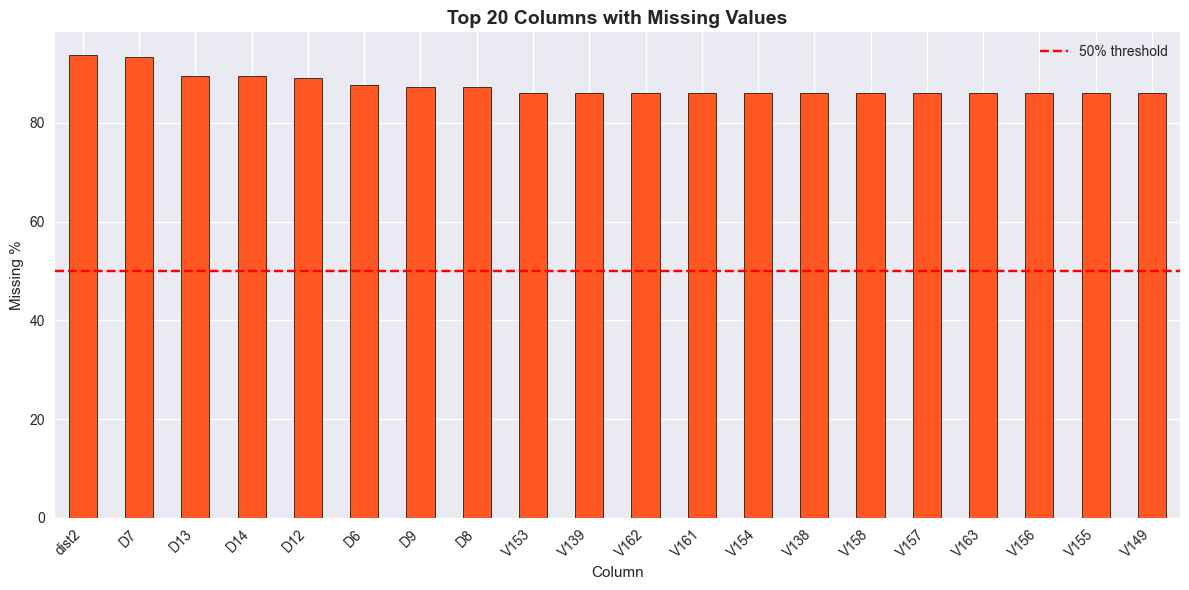

In [ ]:
# Cell 8 — Missing values analysis:


# How much data is missing?
missing = train_tx.isnull().sum()
missing_pct = (missing / len(train_tx) * 100).sort_values(ascending=False)
missing_top20 = missing_pct[missing_pct > 0].head(20)

print(f"Columns with missing values: {(missing > 0).sum()} out of {len(missing)}")
print(f"\nTop 20 columns with most missing data:")
print(missing_top20.to_string())

# Plot
plt.figure(figsize=(12, 6))
missing_top20.plot(kind='bar', color='#FF5722', edgecolor='black', linewidth=0.5)
plt.title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/05_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 9 — Your first fraud pattern findings:

# Summary of what we discovered today
print("=" * 50)
print("DAY 2 — KEY FRAUD PATTERNS DISCOVERED")
print("=" * 50)

fraud_rate = train_tx['isFraud'].mean() * 100
avg_fraud_amt = train_tx[train_tx['isFraud']==1]['TransactionAmt'].mean()
avg_legit_amt = train_tx[train_tx['isFraud']==0]['TransactionAmt'].mean()
top_product = train_tx.groupby('ProductCD')['isFraud'].mean().idxmax()

print(f"\n1. Overall fraud rate:       {fraud_rate:.2f}%")
print(f"2. Avg fraudulent amount:    ${avg_fraud_amt:.2f}")
print(f"3. Avg legitimate amount:    ${avg_legit_amt:.2f}")
print(f"4. Highest risk product:     {top_product}")
print(f"5. Dataset size:             {len(train_tx):,} transactions")
print(f"6. Features available:       {train_tx.shape[1]} columns")
print(f"\nCharts saved to: reports/figures/")
print("\nDay 2 complete. Ready for feature engineering.")

DAY 2 — KEY FRAUD PATTERNS DISCOVERED

1. Overall fraud rate:       3.50%
2. Avg fraudulent amount:    $149.24
3. Avg legitimate amount:    $134.51
4. Highest risk product:     C
5. Dataset size:             590,540 transactions
6. Features available:       394 columns

Charts saved to: reports/figures/

Day 2 complete. Ready for feature engineering.
